# 1. Dataset Audit

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Project root
PROJECT_ROOT = Path.cwd().parent

RAW_DIR = PROJECT_ROOT / "datasets" / "raw"
SYNTHETIC_DIR = PROJECT_ROOT / "datasets" / "synthetic"

REPORT_DIR = PROJECT_ROOT / "reports" / "ml_pipeline"
REPORT_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Raw data:", RAW_DIR)
print("Synthetic data:", SYNTHETIC_DIR)

print("\nProject root exists:", PROJECT_ROOT.exists())
print("Datasets folder exists:", (PROJECT_ROOT / "datasets").exists())
print("Synthetic folder exists:", SYNTHETIC_DIR.exists())

Project root: d:\newwwwwwww\AiBasedInstagramPrediction
Raw data: d:\newwwwwwww\AiBasedInstagramPrediction\datasets\raw
Synthetic data: d:\newwwwwwww\AiBasedInstagramPrediction\datasets\synthetic

Project root exists: True
Datasets folder exists: True
Synthetic folder exists: True


In [2]:
# ============================================================
# 1.1 DATASET INVENTORY
# ============================================================

real_files = sorted(RAW_DIR.rglob("*.csv"))
synthetic_files = sorted(SYNTHETIC_DIR.rglob("*.csv"))

print("REAL DATASETS")
print("=" * 70)

for file in real_files:
    print(file.relative_to(PROJECT_ROOT))

print("\nSYNTHETIC DATASETS")
print("=" * 70)

for file in synthetic_files:
    print(file.relative_to(PROJECT_ROOT))

print("\nTotal real CSV files:", len(real_files))
print("Total synthetic CSV files:", len(synthetic_files))

REAL DATASETS
datasets\raw\Instagram - Posts.csv
datasets\raw\Instagram - Posts2.csv
datasets\raw\instagram_analytics.csv
datasets\raw\instagram_data\captions_csv.csv
datasets\raw\instagram_data2\captions_csv2.csv
datasets\raw\instagram_reach.csv

SYNTHETIC DATASETS
datasets\synthetic\synthetic_instagram_engagement_dataset_100k.csv

Total real CSV files: 6
Total synthetic CSV files: 1


In [3]:
# ============================================================
# 1.2 LOAD SYNTHETIC DATASET
# ============================================================

synthetic_path = (
    SYNTHETIC_DIR /
    "synthetic_instagram_engagement_dataset_100k.csv"
)

synthetic_df = pd.read_csv(
    synthetic_path,
    low_memory=False
)

print("Dataset loaded successfully.")
print("Rows:", f"{len(synthetic_df):,}")
print("Columns:", len(synthetic_df.columns))

display(synthetic_df.head())

Dataset loaded successfully.
Rows: 100,000
Columns: 59


,post_id,account_id,category,account_type,follower_count,following_count,account_age_days,verified_status,posting_frequency,average_historical_engagement,...,estimated_image_quality,likes,comments,shares,saves,reach,impressions,engagement_rate,performance_class,binary_performance
0,POST_00000000,ACC_007298,Education,Influencer,857030,1924,1806,True,6.23,0.00500,...,0.706,432,37,13,27,24805,32279,0.020520,Medium,0
1,POST_00000001,ACC_006437,Technology,Influencer,16373,1767,2787,False,7.89,0.01030,...,0.553,16,2,0,3,754,1017,0.027851,Medium,0
2,POST_00000002,ACC_005231,Entertainment,Business,6624,654,233,False,9.20,0.01404,...,0.653,22,2,2,0,568,1473,0.045775,High,1
3,POST_00000003,ACC_001503,Technology,Business,17668,2199,1356,False,4.09,0.02498,...,0.653,17,5,1,4,647,1669,0.041731,High,1
4,POST_00000004,ACC_002554,Fashion,Brand,80759,428,129,False,8.99,0.01010,...,0.602,24,1,1,5,3858,8790,0.008035,Low,0


In [4]:
# ============================================================
# 1.3 COLUMN INVENTORY
# ============================================================

column_inventory = pd.DataFrame({
    "Column_Number": range(1, len(synthetic_df.columns) + 1),
    "Column_Name": synthetic_df.columns,
    "Data_Type": synthetic_df.dtypes.astype(str).values,
    "Missing_Count": synthetic_df.isna().sum().values,
    "Missing_Percentage": (
        synthetic_df.isna().mean().values * 100
    ).round(2)
})

display(column_inventory)

,Column_Number,Column_Name,Data_Type,Missing_Count,Missing_Percentage
0,1,post_id,str,0,0.00
1,2,account_id,str,0,0.00
2,3,category,str,0,0.00
3,4,account_type,str,0,0.00
4,5,follower_count,int64,0,0.00
5,6,following_count,int64,0,0.00
6,7,account_age_days,int64,0,0.00
7,8,verified_status,bool,0,0.00
8,9,posting_frequency,float64,0,0.00
9,10,average_historical_engagement,float64,0,0.00


In [5]:
# Save the academic dataset schema/inventory

schema_path = REPORT_DIR / "synthetic_dataset_schema.csv"

column_inventory.to_csv(
    schema_path,
    index=False
)

print("Schema saved to:")
print(schema_path)

Schema saved to:
d:\newwwwwwww\AiBasedInstagramPrediction\reports\ml_pipeline\synthetic_dataset_schema.csv


In [6]:
# ============================================================
# 1.4 BASIC DATASET STATISTICS
# ============================================================

print("Dataset Shape")
print("=" * 50)
print(f"Rows    : {synthetic_df.shape[0]:,}")
print(f"Columns : {synthetic_df.shape[1]}")

print("\nNumeric Variables")
print("=" * 50)

numeric_columns = synthetic_df.select_dtypes(
    include=np.number
).columns.tolist()

print(f"Number of numeric variables: {len(numeric_columns)}")

display(
    synthetic_df[numeric_columns].describe().T
)

Dataset Shape
Rows    : 100,000
Columns : 59

Numeric Variables
Number of numeric variables: 42


,count,mean,std,min,25%,50%,75%,max
follower_count,100000.0,31172.261280,96217.795313,50.0000,1920.000000,7690.500000,25383.750000,4.495974e+06
following_count,100000.0,1057.566920,634.823943,50.0000,548.000000,980.000000,1421.000000,2.999000e+03
account_age_days,100000.0,1809.050840,987.373791,90.0000,958.000000,1815.000000,2659.000000,3.499000e+03
posting_frequency,100000.0,5.830593,3.083580,0.5000,3.390000,5.560000,7.730000,1.399000e+01
average_historical_engagement,100000.0,0.022702,0.013434,0.0050,0.013050,0.020540,0.028500,9.984000e-02
caption_length,100000.0,98.395920,26.559061,42.0000,77.000000,97.000000,115.000000,2.150000e+02
word_count,100000.0,15.201880,4.746358,7.0000,11.000000,15.000000,18.000000,3.400000e+01
sentence_count,100000.0,3.065750,0.763788,1.0000,3.000000,3.000000,3.000000,7.000000e+00
hashtag_count,100000.0,7.343770,1.717668,4.0000,6.000000,7.000000,9.000000,1.300000e+01
emoji_count,100000.0,1.644010,1.086790,0.0000,1.000000,2.000000,2.000000,5.000000e+00


In [7]:
# ============================================================
# 1.5 CATEGORICAL VARIABLES
# ============================================================

categorical_columns = synthetic_df.select_dtypes(
    include=["object", "bool", "category"]
).columns.tolist()

print(
    f"Number of categorical/text variables: "
    f"{len(categorical_columns)}"
)

for column in categorical_columns:
    print("\n" + "-" * 60)
    print(f"{column}")
    print("-" * 60)
    print(
        synthetic_df[column]
        .value_counts(dropna=False)
        .head(15)
    )

Number of categorical/text variables: 17

------------------------------------------------------------
post_id
------------------------------------------------------------
post_id
POST_00000000    1
POST_00000001    1
POST_00000002    1
POST_00000003    1
POST_00000004    1
POST_00000005    1
POST_00000006    1
POST_00000007    1
POST_00000008    1
POST_00000009    1
POST_00000010    1
POST_00000011    1
POST_00000012    1
POST_00000013    1
POST_00000014    1
Name: count, dtype: int64

------------------------------------------------------------
account_id
------------------------------------------------------------
account_id
ACC_001143    27
ACC_001243    27
ACC_002447    27
ACC_001598    26
ACC_001408    26
ACC_003975    26
ACC_000642    25
ACC_002698    25
ACC_003442    25
ACC_007223    25
ACC_002963    25
ACC_007191    25
ACC_000879    24
ACC_006204    24
ACC_005465    24
Name: count, dtype: int64

------------------------------------------------------------
category
------------

C:\Users\User\AppData\Local\Temp\ipykernel_484\3226063535.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = synthetic_df.select_dtypes(


In [8]:
# ============================================================
# 1.6 MISSING VALUE AUDIT
# ============================================================

missing_summary = pd.DataFrame({
    "Column": synthetic_df.columns,
    "Missing_Count": synthetic_df.isna().sum(),
    "Missing_Percentage": (
        synthetic_df.isna().mean() * 100
    ).round(2)
})

missing_summary = (
    missing_summary[
        missing_summary["Missing_Count"] > 0
    ]
    .sort_values(
        "Missing_Percentage",
        ascending=False
    )
)

print("VARIABLES WITH MISSING VALUES")
print("=" * 70)

display(missing_summary)

print(
    f"\nVariables containing missing values: "
    f"{len(missing_summary)}"
)

VARIABLES WITH MISSING VALUES


,Column,Missing_Count,Missing_Percentage
saturation,saturation,3530,3.53
sharpness,sharpness,3108,3.11
visual_complexity,visual_complexity,3088,3.09
text_in_image,text_in_image,3084,3.08
brightness,brightness,3075,3.08
contrast,contrast,3055,3.06
colorfulness,colorfulness,3020,3.02
estimated_image_quality,estimated_image_quality,2995,3.00
face_count,face_count,2576,2.58
image_width,image_width,2070,2.07



Variables containing missing values: 14


In [9]:
# ============================================================
# 1.7 DUPLICATE RECORD AUDIT
# ============================================================

duplicate_rows = synthetic_df.duplicated().sum()

duplicate_post_ids = (
    synthetic_df["post_id"].duplicated().sum()
)

duplicate_account_ids = (
    synthetic_df["account_id"].duplicated().sum()
)

print("DUPLICATE AUDIT")
print("=" * 70)

print(f"Duplicate complete rows : {duplicate_rows:,}")
print(f"Duplicate post IDs      : {duplicate_post_ids:,}")
print(f"Repeated account IDs    : {duplicate_account_ids:,}")

print(
    "\nNote: Repeated account IDs are expected because "
    "one account can publish multiple posts."
)

DUPLICATE AUDIT
Duplicate complete rows : 0
Duplicate post IDs      : 0
Repeated account IDs    : 92,001

Note: Repeated account IDs are expected because one account can publish multiple posts.


,Performance Class,Count,Percentage
0,0,49982,49.98
1,1,50018,50.02


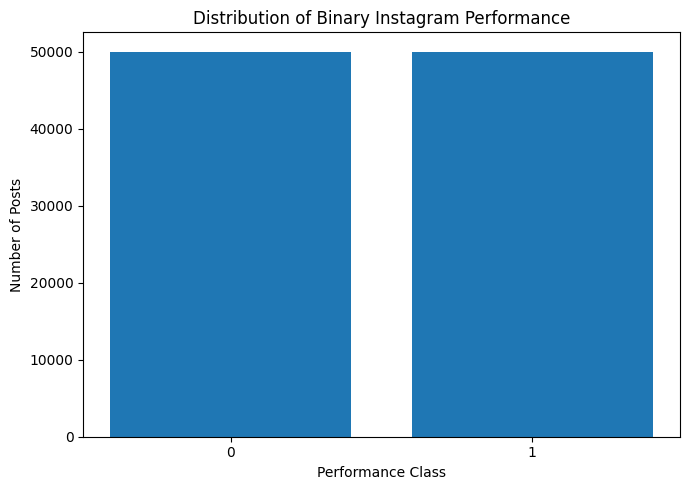

In [10]:
# ============================================================
# 1.8 TARGET DISTRIBUTION
# ============================================================

target_counts = (
    synthetic_df["binary_performance"]
    .value_counts()
    .sort_index()
)

target_percentages = (
    target_counts /
    len(synthetic_df) *
    100
).round(2)

target_summary = pd.DataFrame({
    "Performance Class": target_counts.index,
    "Count": target_counts.values,
    "Percentage": target_percentages.values
})

display(target_summary)

# Visualization

plt.figure(figsize=(7, 5))

plt.bar(
    target_summary["Performance Class"].astype(str),
    target_summary["Count"]
)

plt.title("Distribution of Binary Instagram Performance")
plt.xlabel("Performance Class")
plt.ylabel("Number of Posts")

plt.tight_layout()
plt.show()

In [11]:
# ============================================================
# 1.9 TARGET LEAKAGE AUDIT
# ============================================================

target_and_outcome_columns = [
    "likes",
    "comments",
    "shares",
    "saves",
    "reach",
    "impressions",
    "engagement_rate",
    "performance_class",
    "binary_performance"
]

identifier_columns = [
    "post_id",
    "account_id"
]

leakage_columns = [
    col
    for col in target_and_outcome_columns
    if col in synthetic_df.columns
]

print("TARGET / POST-PUBLICATION VARIABLES")
print("=" * 70)

for col in leakage_columns:
    print(f"✓ {col}")

print("\nIDENTIFIER VARIABLES")
print("=" * 70)

for col in identifier_columns:
    if col in synthetic_df.columns:
        print(f"✓ {col}")

print("\nThese variables will NOT be used as direct ML predictors.")

TARGET / POST-PUBLICATION VARIABLES
✓ likes
✓ comments
✓ shares
✓ saves
✓ reach
✓ impressions
✓ engagement_rate
✓ performance_class
✓ binary_performance

IDENTIFIER VARIABLES
✓ post_id
✓ account_id

These variables will NOT be used as direct ML predictors.


In [12]:
# ============================================================
# 1.10 DERIVED TEXT FEATURE CONSISTENCY
# ============================================================

import re

# Caption length
calculated_caption_length = (
    synthetic_df["caption"]
    .fillna("")
    .astype(str)
    .str.len()
)

caption_length_mismatch = (
    calculated_caption_length
    != synthetic_df["caption_length"]
)

# Word count
calculated_word_count = (
    synthetic_df["caption"]
    .fillna("")
    .astype(str)
    .str.split()
    .str.len()
)

word_count_mismatch = (
    calculated_word_count
    != synthetic_df["word_count"]
)

# Hashtag count
def calculate_hashtag_count(text):
    if pd.isna(text):
        return 0

    return len(
        re.findall(
            r"(?<!\w)#\w+",
            str(text)
        )
    )

calculated_hashtag_count = (
    synthetic_df["hashtags"]
    .fillna("")
    .apply(calculate_hashtag_count)
)

hashtag_count_mismatch = (
    calculated_hashtag_count
    != synthetic_df["hashtag_count"]
)

print("DERIVED FEATURE CONSISTENCY")
print("=" * 70)

print(
    "Caption length mismatches :",
    f"{caption_length_mismatch.sum():,}"
)

print(
    "Word count mismatches     :",
    f"{word_count_mismatch.sum():,}"
)

print(
    "Hashtag count mismatches  :",
    f"{hashtag_count_mismatch.sum():,}"
)

DERIVED FEATURE CONSISTENCY
Caption length mismatches : 0
Word count mismatches     : 79,752
Hashtag count mismatches  : 3,834


In [13]:
# ============================================================
# 1.11 WORD COUNT MISMATCH INVESTIGATION
# ============================================================

word_check = pd.DataFrame({
    "post_id": synthetic_df["post_id"],
    "caption": synthetic_df["caption"],
    "stored_word_count": synthetic_df["word_count"],
    "calculated_word_count": calculated_word_count
})

word_check["difference"] = (
    word_check["stored_word_count"]
    - word_check["calculated_word_count"]
)

word_mismatches = word_check[
    word_check["difference"] != 0
].copy()

print("WORD COUNT MISMATCH ANALYSIS")
print("=" * 70)

print(
    "Total mismatches:",
    f"{len(word_mismatches):,}"
)

print(
    "Mismatch percentage:",
    f"{len(word_mismatches) / len(synthetic_df) * 100:.2f}%"
)

print("\nDifference distribution:")

display(
    word_mismatches["difference"]
    .value_counts()
    .sort_index()
    .head(20)
)

print("\nSample mismatches:")

display(
    word_mismatches.head(20)
)

WORD COUNT MISMATCH ANALYSIS
Total mismatches: 79,752
Mismatch percentage: 79.75%

Difference distribution:


difference
-7       10
-6      116
-5      460
-4     4086
-3    12085
-2    23075
-1    29684
 1     7405
 2     2257
 3      556
 4       18
Name: count, dtype: int64


Sample mismatches:


,post_id,caption,stored_word_count,calculated_word_count,difference
0,POST_00000000,Breaking down complex concepts in spaced repet...,18,17,1
1,POST_00000001,From idea to prototype in 6 days using cyberse...,14,15,-1
4,POST_00000004,Color palette of the week: bold and unapologet...,25,26,-1
5,POST_00000005,Accessorize like a pro with these silk scarf t...,18,19,-1
6,POST_00000006,Mind-muscle connection is everything. Focus on...,23,22,1
7,POST_00000007,Color palette of the week: bold and unapologet...,19,20,-1
9,POST_00000009,Just finished watching synthwave album. Plot t...,10,12,-2
10,POST_00000010,Progress over perfection. 29 weeks of consiste...,10,11,-1
11,POST_00000011,Concert energy is unmatched. Live music hits d...,8,10,-2
12,POST_00000012,How I went from struggling to acing data liter...,17,15,2


In [14]:
# ============================================================
# 1.12 WORD COUNT STATISTICAL COMPARISON
# ============================================================

word_comparison = pd.DataFrame({
    "Metric": [
        "Stored word count mean",
        "Calculated word count mean",
        "Stored word count median",
        "Calculated word count median",
        "Stored minimum",
        "Calculated minimum",
        "Stored maximum",
        "Calculated maximum"
    ],
    "Value": [
        synthetic_df["word_count"].mean(),
        calculated_word_count.mean(),
        synthetic_df["word_count"].median(),
        calculated_word_count.median(),
        synthetic_df["word_count"].min(),
        calculated_word_count.min(),
        synthetic_df["word_count"].max(),
        calculated_word_count.max()
    ]
})

display(word_comparison)

,Metric,Value
0,Stored word count mean,15.20188
1,Calculated word count mean,16.38028
2,Stored word count median,15.00000
3,Calculated word count median,16.00000
4,Stored minimum,7.00000
5,Calculated minimum,7.00000
6,Stored maximum,34.00000
7,Calculated maximum,37.00000


In [15]:
# ============================================================
# 1.13 HASHTAG COUNT MISMATCH INVESTIGATION
# ============================================================

hashtag_check = pd.DataFrame({
    "post_id": synthetic_df["post_id"],
    "hashtags": synthetic_df["hashtags"],
    "stored_hashtag_count": synthetic_df["hashtag_count"],
    "calculated_hashtag_count": calculated_hashtag_count
})

hashtag_check["difference"] = (
    hashtag_check["stored_hashtag_count"]
    - hashtag_check["calculated_hashtag_count"]
)

hashtag_mismatches = hashtag_check[
    hashtag_check["difference"] != 0
].copy()

print("HASHTAG COUNT MISMATCH ANALYSIS")
print("=" * 70)

print(
    "Total mismatches:",
    f"{len(hashtag_mismatches):,}"
)

print(
    "Mismatch percentage:",
    f"{len(hashtag_mismatches) / len(synthetic_df) * 100:.2f}%"
)

print("\nDifference distribution:")

display(
    hashtag_mismatches["difference"]
    .value_counts()
    .sort_index()
)

print("\nSample mismatches:")

display(
    hashtag_mismatches.head(20)
)

HASHTAG COUNT MISMATCH ANALYSIS
Total mismatches: 3,834
Mismatch percentage: 3.83%

Difference distribution:


difference
1    3793
2      41
Name: count, dtype: int64


Sample mismatches:


,post_id,hashtags,stored_hashtag_count,calculated_hashtag_count,difference
37,POST_00000037,#notes #education #study tips #examprep #educa...,10,9,1
98,POST_00000098,#education #study tips #lifelonglearning #stud...,8,7,1
104,POST_00000104,#study #skilldevelopment #onlinelearning #stud...,9,8,1
156,POST_00000156,#study tips #edtech #notes #reels #trending #b...,9,8,1
186,POST_00000186,#love #study #study tips #university #academic...,8,7,1
210,POST_00000210,#lifelonglearning #academic #research #learnin...,11,10,1
224,POST_00000224,#lifelonglearning #study tips #onlinelearning ...,10,9,1
241,POST_00000241,#university #instagram #reels #study #study ti...,8,7,1
272,POST_00000272,#study tips #student #studygram #like #school ...,7,6,1
281,POST_00000281,#studygram #study tips #learning #tutorial #reels,6,5,1


In [16]:
# ============================================================
# 1.14 ENGAGEMENT CONSISTENCY AUDIT
# ============================================================

calculated_engagement_rate = (
    (
        synthetic_df["likes"]
        + synthetic_df["comments"]
        + synthetic_df["shares"]
        + synthetic_df["saves"]
    )
    / synthetic_df["reach"].replace(0, np.nan)
)

engagement_difference = (
    calculated_engagement_rate
    - synthetic_df["engagement_rate"]
).abs()

print("ENGAGEMENT CONSISTENCY AUDIT")
print("=" * 70)

print(
    "Maximum engagement-rate difference:",
    engagement_difference.max()
)

print(
    "Mean engagement-rate difference:",
    engagement_difference.mean()
)

print(
    "Exact/near matches:",
    (engagement_difference < 1e-6).sum(),
    "/",
    len(synthetic_df)
)

print(
    "Invalid reach values:",
    (synthetic_df["reach"] <= 0).sum()
)

print(
    "Impressions < reach:",
    (
        synthetic_df["impressions"]
        < synthetic_df["reach"]
    ).sum()
)

ENGAGEMENT CONSISTENCY AUDIT
Maximum engagement-rate difference: 5.000000000143778e-07
Mean engagement-rate difference: 2.130049279894628e-07
Exact/near matches: 100000 / 100000
Invalid reach values: 0
Impressions < reach: 0


In [17]:
# ============================================================
# 1.15 IMAGE FEATURE AUDIT
# ============================================================

image_columns = [
    "has_image",
    "image_width",
    "image_height",
    "aspect_ratio",
    "brightness",
    "contrast",
    "saturation",
    "sharpness",
    "colorfulness",
    "face_count",
    "text_in_image",
    "visual_complexity",
    "estimated_image_quality"
]

image_audit = pd.DataFrame({
    "Feature": image_columns,
    "Missing_Count": [
        synthetic_df[col].isna().sum()
        for col in image_columns
    ],
    "Missing_Percentage": [
        synthetic_df[col].isna().mean() * 100
        for col in image_columns
    ]
})

image_audit["Missing_Percentage"] = (
    image_audit["Missing_Percentage"].round(2)
)

display(image_audit)

,Feature,Missing_Count,Missing_Percentage
0,has_image,0,0.00
1,image_width,2070,2.07
2,image_height,1950,1.95
3,aspect_ratio,2022,2.02
4,brightness,3075,3.08
5,contrast,3055,3.06
6,saturation,3530,3.53
7,sharpness,3108,3.11
8,colorfulness,3020,3.02
9,face_count,2576,2.58


In [18]:
# ============================================================
# 1.16 ACCOUNT DISTRIBUTION
# ============================================================

account_summary = (
    synthetic_df
    .groupby("account_id")
    .size()
    .describe()
)

print("ACCOUNT POST DISTRIBUTION")
print("=" * 70)

display(account_summary)

print(
    "Unique accounts:",
    synthetic_df["account_id"].nunique()
)

print(
    "Average posts per account:",
    len(synthetic_df)
    / synthetic_df["account_id"].nunique()
)

ACCOUNT POST DISTRIBUTION


count    7999.000000
mean       12.501563
std         3.497181
min         2.000000
25%        10.000000
50%        12.000000
75%        15.000000
max        27.000000
dtype: float64

Unique accounts: 7999
Average posts per account: 12.501562695336917


In [19]:
# ============================================================
# 1.17 DATASET AUDIT SUMMARY
# ============================================================

audit_summary = pd.DataFrame({
    "Audit Item": [
        "Total records",
        "Total variables",
        "Duplicate rows",
        "Duplicate post IDs",
        "Unique accounts",
        "Binary class 0 (%)",
        "Binary class 1 (%)",
        "Variables with missing values",
        "Caption length mismatches",
        "Word count mismatches",
        "Hashtag count mismatches",
        "Impressions below reach"
    ],
    
    "Result": [
        len(synthetic_df),
        len(synthetic_df.columns),
        synthetic_df.duplicated().sum(),
        synthetic_df["post_id"].duplicated().sum(),
        synthetic_df["account_id"].nunique(),
        target_percentages.iloc[0],
        target_percentages.iloc[1],
        len(missing_summary),
        caption_length_mismatch.sum(),
        word_count_mismatch.sum(),
        hashtag_count_mismatch.sum(),
        (
            synthetic_df["impressions"]
            < synthetic_df["reach"]
        ).sum()
    ]
})

display(audit_summary)

audit_summary.to_csv(
    REPORT_DIR / "dataset_audit_summary.csv",
    index=False
)

print(
    "\nAudit summary saved to:",
    REPORT_DIR / "dataset_audit_summary.csv"
)

,Audit Item,Result
0,Total records,100000.00
1,Total variables,59.00
2,Duplicate rows,0.00
3,Duplicate post IDs,0.00
4,Unique accounts,7999.00
5,Binary class 0 (%),49.98
6,Binary class 1 (%),50.02
7,Variables with missing values,14.00
8,Caption length mismatches,0.00
9,Word count mismatches,79752.00



Audit summary saved to: d:\newwwwwwww\AiBasedInstagramPrediction\reports\ml_pipeline\dataset_audit_summary.csv
